# TF-IDF + MACHINE LEARNING
## Vetorização TF-IDF com texto stemmed + Naive Bayes, SVM, Random Forest, Regressão Logística e Gradient Boosting

**Objetivo:**
1. Usar texto com stemming (do Notebook 3)
2. Vetorizar com TF-IDF
3. Treinar 5 modelos de ML
4. Avaliar com métricas completas
5. Gerar matrizes de confusão
6. Aplicar LIME e SHAP para interpretabilidade

## 1. IMPORTAÇÕES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Vetorização
from sklearn.feature_extraction.text import TfidfVectorizer

# Split e métricas
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

# Modelos
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Interpretabilidade
from lime.lime_text import LimeTextExplainer
import shap

# Salvar modelos
import joblib

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Bibliotecas importadas!")

✅ Bibliotecas importadas!


## 2. CARREGAR DADOS COM PLN

Vamos usar a coluna `texto_stemmed` que foi gerada no Notebook 3.

In [2]:
# Carregar dados processados
df = pd.read_csv('../data/processed/reviews_pln.csv')

print("="*80)
print("📊 DADOS CARREGADOS")
print("="*80)
print(f"Total de reviews: {len(df):,}")
print(f"\nColunas disponíveis: {list(df.columns)}")
print(f"\nDistribuição de sentimentos:")
print(df['sentimento'].value_counts())
print(f"\nPrimeiras linhas:")
display(df[['texto', 'texto_stemmed', 'sentimento']].head())

📊 DADOS CARREGADOS
Total de reviews: 3,789

Colunas disponíveis: ['texto', 'nota', 'data', 'app', 'sentimento', 'texto_preprocessado', 'texto_stemmed', 'texto_lemmatized']

Distribuição de sentimentos:
sentimento
Negativo    1263
Neutro      1263
Positivo    1263
Name: count, dtype: int64

Primeiras linhas:


,texto,texto_stemmed,sentimento
0,Lixo,lix,Negativo
1,Muito caro,car,Negativo
2,está fora de cervidor já usei antes e agora nã...,cerv use ant agor funcion,Negativo
3,"Esse app sempre foi muito bom, mas há algumas ...",app sempr bom algum seman abr sempr volt tel i...,Negativo
4,"é útil? é. Mas e MUITO mal feito pqp, além de ...",útil mal feit pqp além sempr trav pi moment co...,Negativo


## 3. PREPARAR DADOS

Vamos usar o texto com **stemming** e mapear os sentimentos para números.

In [3]:
# Usar texto stemmed
X = df['texto_stemmed'].fillna('')  # Remover NaN se houver

# Mapear sentimentos para números
sentimento_map = {'Positivo': 2, 'Neutro': 1, 'Negativo': 0}
y = df['sentimento'].map(sentimento_map)

print("✅ Dados preparados!")
print(f"\nExemplo de texto stemmed:")
print(f"   {X.iloc[0][:100]}...")
print(f"\nMapeamento: {sentimento_map}")

✅ Dados preparados!

Exemplo de texto stemmed:
   lix...

Mapeamento: {'Positivo': 2, 'Neutro': 1, 'Negativo': 0}


## 4. DIVISÃO TREINO/TESTE

80% treino, 20% teste, com estratificação para manter proporção das classes.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("="*80)
print("📊 DIVISÃO DOS DADOS")
print("="*80)
print(f"Treino: {len(X_train):,} amostras")
print(f"Teste:  {len(X_test):,} amostras")

print(f"\nDistribuição Treino:")
print(pd.Series(y_train).value_counts().sort_index())

print(f"\nDistribuição Teste:")
print(pd.Series(y_test).value_counts().sort_index())

📊 DIVISÃO DOS DADOS
Treino: 3,031 amostras
Teste:  758 amostras

Distribuição Treino:
sentimento
0    1011
1    1010
2    1010
Name: count, dtype: int64

Distribuição Teste:
sentimento
0    252
1    253
2    253
Name: count, dtype: int64


## 5. VETORIZAÇÃO TF-IDF

**TF-IDF** (Term Frequency - Inverse Document Frequency) transforma textos em vetores numéricos.

**Configurações:**
- `max_features=5000`: Usar as 5000 palavras mais importantes
- `ngram_range=(1,2)`: Considerar palavras individuais e pares de palavras

In [5]:
print("🔄 Vetorizando com TF-IDF...")

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,  # Palavra deve aparecer em pelo menos 2 documentos
    max_df=0.95  # Remover palavras que aparecem em mais de 95% dos docs
)

# Fit no treino e transform em ambos
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\n✅ Vetorização concluída!")
print(f"\n📊 Shape dos dados:")
print(f"   X_train_tfidf: {X_train_tfidf.shape}")
print(f"   X_test_tfidf:  {X_test_tfidf.shape}")
print(f"\n💡 Interpretação:")
print(f"   - {X_train_tfidf.shape[0]:,} amostras de treino")
print(f"   - {X_train_tfidf.shape[1]:,} features (palavras/bigramas)")

# Salvar vetorizador
os.makedirs('../results/models', exist_ok=True)
joblib.dump(tfidf, '../results/models/tfidf_vectorizer.pkl')
print(f"\n💾 Vetorizador salvo em: ../results/models/tfidf_vectorizer.pkl")

🔄 Vetorizando com TF-IDF...

✅ Vetorização concluída!

📊 Shape dos dados:
   X_train_tfidf: (3031, 4144)
   X_test_tfidf:  (758, 4144)

💡 Interpretação:
   - 3,031 amostras de treino
   - 4,144 features (palavras/bigramas)

💾 Vetorizador salvo em: ../results/models/tfidf_vectorizer.pkl


##  6. FUNÇÃO PARA TREINAR E AVALIAR MODELOS

Vamos criar uma função genérica que:
1. Treina o modelo
2. Faz predições
3. Calcula métricas
4. Salva o modelo

In [7]:
def treinar_avaliar_modelo(nome, modelo, X_train, X_test, y_train, y_test):
    """
    Treina e avalia um modelo de ML
    
    Args:
        nome (str): Nome do modelo
        modelo: Instância do modelo sklearn
        X_train, X_test, y_train, y_test: Dados de treino/teste
    
    Returns:
        dict: Resultados do modelo
    """
    print(f"\n{'='*80}")
    print(f"🤖 TREINANDO: {nome}")
    print(f"{'='*80}")
    
    # Treinar
    print(f"⏳ Treinando...")
    modelo.fit(X_train, y_train)
    
    # Predições
    y_pred = modelo.predict(X_test)
    
    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    print(f"\n📊 MÉTRICAS:")
    print(f"   Acurácia:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"   Precisão:  {prec:.4f}")
    print(f"   Recall:    {rec:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    
    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n📋 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Negativo', 'Neutro', 'Positivo']))
    
    # Salvar modelo
    filename = f"../results/models/{nome.lower().replace(' ', '_')}_tfidf.pkl"
    joblib.dump(modelo, filename)
    print(f"\n💾 Modelo salvo em: {filename}")
    
    return {
        'nome': nome,
        'modelo': modelo,
        'acuracia': acc,
        'precisao': prec,
        'recall': rec,
        'f1': f1,
        'predicoes': y_pred,
        'matriz_confusao': cm
    }

print("✅ Função definida!")

✅ Função definida!


## 7. TREINAR OS 5 MODELOS

Vamos treinar cada um dos 5 modelos de Machine Learning.

### 7.1 Naive Bayes

In [8]:
nb_model = MultinomialNB()
resultado_nb = treinar_avaliar_modelo('Naive Bayes', nb_model, X_train_tfidf, X_test_tfidf, y_train, y_test)


🤖 TREINANDO: Naive Bayes
⏳ Treinando...

📊 MÉTRICAS:
   Acurácia:  0.6504 (65.04%)
   Precisão:  0.6478
   Recall:    0.6504
   F1-Score:  0.6489

📋 Classification Report:
              precision    recall  f1-score   support

    Negativo       0.64      0.66      0.65       252
      Neutro       0.55      0.52      0.53       253
    Positivo       0.76      0.77      0.77       253

    accuracy                           0.65       758
   macro avg       0.65      0.65      0.65       758
weighted avg       0.65      0.65      0.65       758


💾 Modelo salvo em: ../results/models/naive_bayes_tfidf.pkl


### 7.2 SVM (Support Vector Machine)

In [9]:
svm_model = SVC(kernel='linear', random_state=42)
resultado_svm = treinar_avaliar_modelo('SVM', svm_model, X_train_tfidf, X_test_tfidf, y_train, y_test)


🤖 TREINANDO: SVM
⏳ Treinando...

📊 MÉTRICAS:
   Acurácia:  0.6464 (64.64%)
   Precisão:  0.6448
   Recall:    0.6464
   F1-Score:  0.6453

📋 Classification Report:
              precision    recall  f1-score   support

    Negativo       0.61      0.65      0.63       252
      Neutro       0.54      0.51      0.53       253
    Positivo       0.78      0.78      0.78       253

    accuracy                           0.65       758
   macro avg       0.64      0.65      0.65       758
weighted avg       0.64      0.65      0.65       758


💾 Modelo salvo em: ../results/models/svm_tfidf.pkl


### 7.3 Random Forest

In [10]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
resultado_rf = treinar_avaliar_modelo('Random Forest', rf_model, X_train_tfidf, X_test_tfidf, y_train, y_test)


🤖 TREINANDO: Random Forest
⏳ Treinando...

📊 MÉTRICAS:
   Acurácia:  0.6214 (62.14%)
   Precisão:  0.6147
   Recall:    0.6214
   F1-Score:  0.6143

📋 Classification Report:
              precision    recall  f1-score   support

    Negativo       0.59      0.67      0.63       252
      Neutro       0.54      0.42      0.48       253
    Positivo       0.71      0.77      0.74       253

    accuracy                           0.62       758
   macro avg       0.61      0.62      0.61       758
weighted avg       0.61      0.62      0.61       758


💾 Modelo salvo em: ../results/models/random_forest_tfidf.pkl


### 7.4 Regressão Logística

In [11]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
resultado_lr = treinar_avaliar_modelo('Regressão Logística', lr_model, X_train_tfidf, X_test_tfidf, y_train, y_test)


🤖 TREINANDO: Regressão Logística
⏳ Treinando...

📊 MÉTRICAS:
   Acurácia:  0.6504 (65.04%)
   Precisão:  0.6489
   Recall:    0.6504
   F1-Score:  0.6484

📋 Classification Report:
              precision    recall  f1-score   support

    Negativo       0.61      0.68      0.65       252
      Neutro       0.56      0.50      0.53       253
    Positivo       0.78      0.77      0.77       253

    accuracy                           0.65       758
   macro avg       0.65      0.65      0.65       758
weighted avg       0.65      0.65      0.65       758


💾 Modelo salvo em: ../results/models/regressão_logística_tfidf.pkl


### 7.5 Gradient Boosting

In [12]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
resultado_gb = treinar_avaliar_modelo('Gradient Boosting', gb_model, X_train_tfidf, X_test_tfidf, y_train, y_test)


🤖 TREINANDO: Gradient Boosting
⏳ Treinando...

📊 MÉTRICAS:
   Acurácia:  0.6135 (61.35%)
   Precisão:  0.6115
   Recall:    0.6135
   F1-Score:  0.6090

📋 Classification Report:
              precision    recall  f1-score   support

    Negativo       0.57      0.69      0.63       252
      Neutro       0.53      0.43      0.47       253
    Positivo       0.73      0.72      0.73       253

    accuracy                           0.61       758
   macro avg       0.61      0.61      0.61       758
weighted avg       0.61      0.61      0.61       758


💾 Modelo salvo em: ../results/models/gradient_boosting_tfidf.pkl


## 📊 8. COMPARAÇÃO DE RESULTADOS

In [13]:
# Compilar resultados
resultados = [resultado_nb, resultado_svm, resultado_rf, resultado_lr, resultado_gb]

df_resultados = pd.DataFrame([{
    'Modelo': r['nome'],
    'Acurácia': r['acuracia'],
    'Precisão': r['precisao'],
    'Recall': r['recall'],
    'F1-Score': r['f1']
} for r in resultados])

df_resultados = df_resultados.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("="*80)
print("📊 COMPARAÇÃO FINAL - TF-IDF + 5 MODELOS ML")
print("="*80)
display(df_resultados.style.background_gradient(cmap='RdYlGn', subset=['F1-Score']))

# Salvar métricas
os.makedirs('../results/metrics', exist_ok=True)
df_resultados.to_csv('../results/metrics/04_metricas_tfidf.csv', index=False)
print(f"\n💾 Métricas salvas em: ../results/metrics/04_metricas_tfidf.csv")

print(f"\n🏆 Melhor modelo: {df_resultados.iloc[0]['Modelo']}")
print(f"📊 F1-Score: {df_resultados.iloc[0]['F1-Score']:.4f}")

📊 COMPARAÇÃO FINAL - TF-IDF + 5 MODELOS ML


,Modelo,Acurácia,Precisão,Recall,F1-Score
0,Naive Bayes,0.650396,0.647848,0.650396,0.648923
1,Regressão Logística,0.650396,0.648887,0.650396,0.648440
2,SVM,0.646438,0.644818,0.646438,0.645310
3,Random Forest,0.621372,0.614715,0.621372,0.614256
4,Gradient Boosting,0.613456,0.611485,0.613456,0.609000



💾 Métricas salvas em: ../results/metrics/04_metricas_tfidf.csv

🏆 Melhor modelo: Naive Bayes
📊 F1-Score: 0.6489


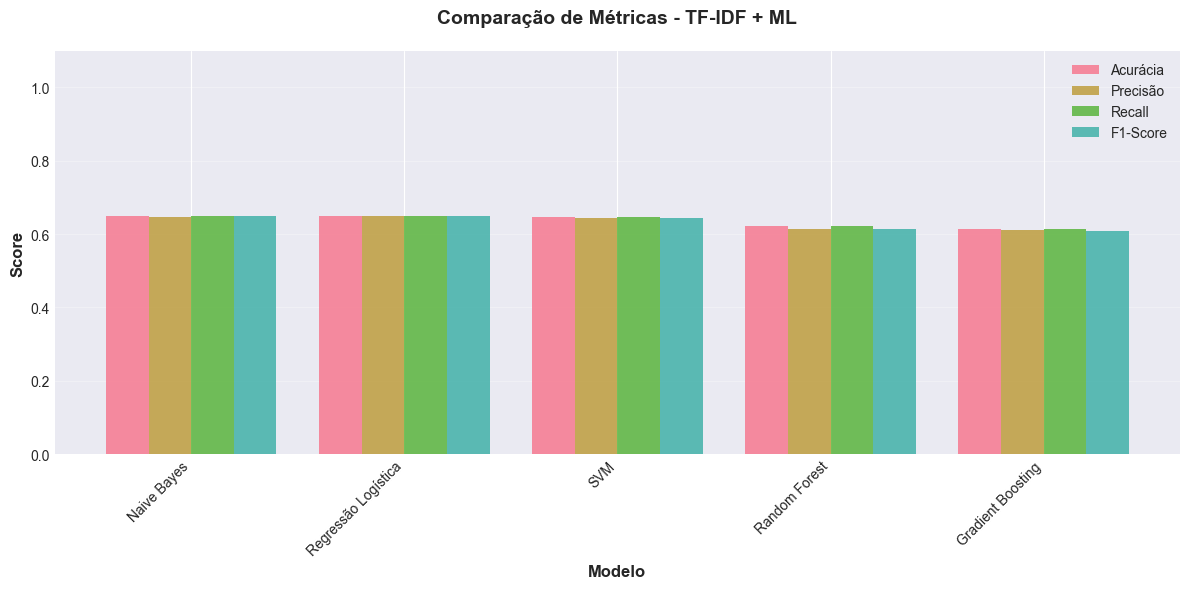

💾 Gráfico salvo: ../results/figures/04_comparacao_metricas.png


In [14]:
# Visualização comparativa
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_resultados))
width = 0.2

bars1 = ax.bar(x - 1.5*width, df_resultados['Acurácia'], width, label='Acurácia', alpha=0.8)
bars2 = ax.bar(x - 0.5*width, df_resultados['Precisão'], width, label='Precisão', alpha=0.8)
bars3 = ax.bar(x + 0.5*width, df_resultados['Recall'], width, label='Recall', alpha=0.8)
bars4 = ax.bar(x + 1.5*width, df_resultados['F1-Score'], width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Modelo', fontweight='bold', fontsize=12)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('Comparação de Métricas - TF-IDF + ML', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_resultados['Modelo'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)

plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/04_comparacao_metricas.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Gráfico salvo: ../results/figures/04_comparacao_metricas.png")

## 🎨 9. MATRIZES DE CONFUSÃO

Visualizar as matrizes de confusão de todos os modelos para entender onde cada um erra.

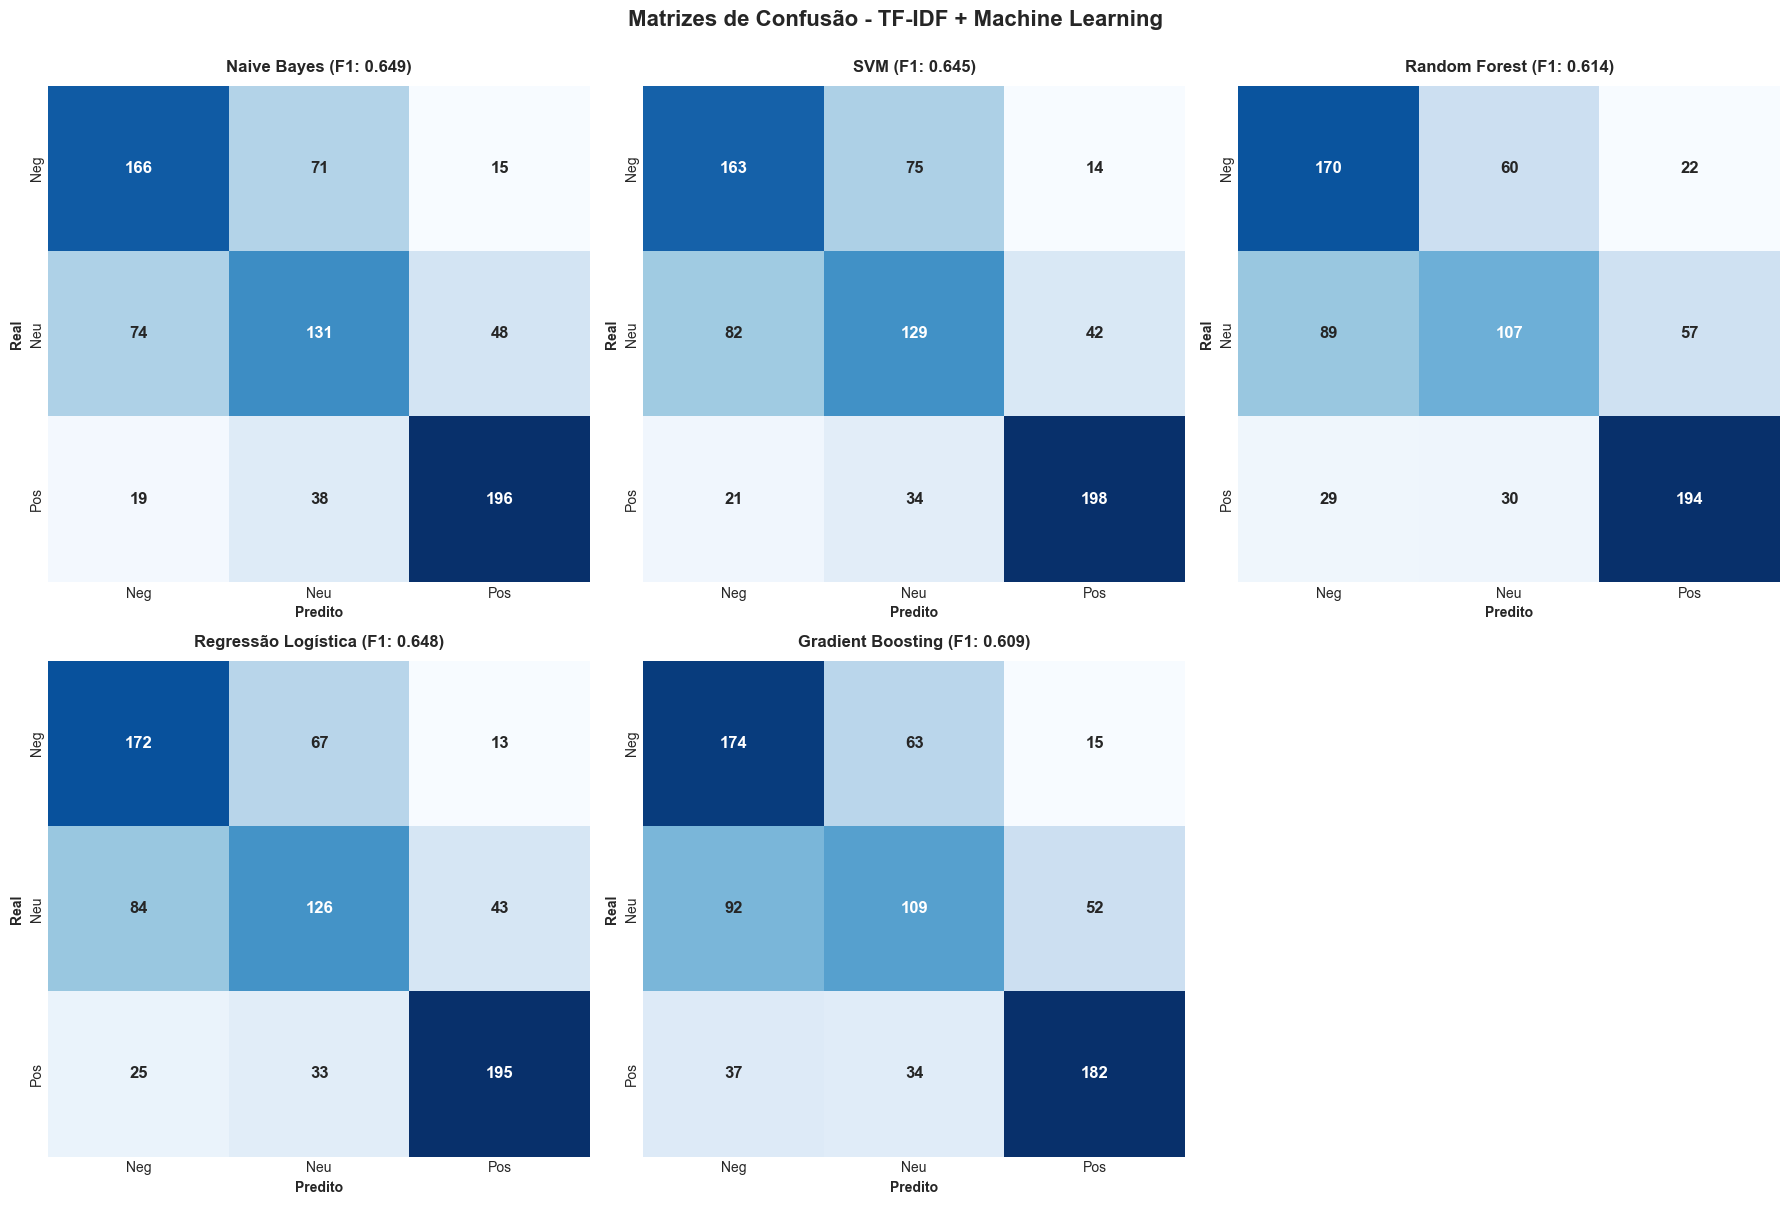

💾 Matrizes de confusão salvas: ../results/figures/04_matrizes_confusao.png


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, resultado in enumerate(resultados):
    cm = resultado['matriz_confusao']
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Neg', 'Neu', 'Pos'],
        yticklabels=['Neg', 'Neu', 'Pos'],
        ax=axes[idx],
        cbar=False,
        annot_kws={'size': 12, 'weight': 'bold'}
    )
    axes[idx].set_title(f"{resultado['nome']} (F1: {resultado['f1']:.3f})", 
                        fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_ylabel('Real', fontweight='bold')
    axes[idx].set_xlabel('Predito', fontweight='bold')

# Remover último subplot (vazio)
fig.delaxes(axes[5])

plt.suptitle('Matrizes de Confusão - TF-IDF + Machine Learning', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/figures/04_matrizes_confusao.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Matrizes de confusão salvas: ../results/figures/04_matrizes_confusao.png")

## 🔍 10. INTERPRETABILIDADE COM LIME

**LIME** (Local Interpretable Model-agnostic Explanations) explica predições individuais mostrando quais palavras influenciaram a decisão do modelo.

🔍 Aplicando LIME no modelo: Naive Bayes

📝 Exemplo selecionado (índice 10):
   Texto original: muito seguro e bom...
   Real: Positivo
   Predito: Positivo
   ✅ ACERTO

🔍 Palavras mais importantes para a predição:
   segur           → -0.100
   bom             → +0.035


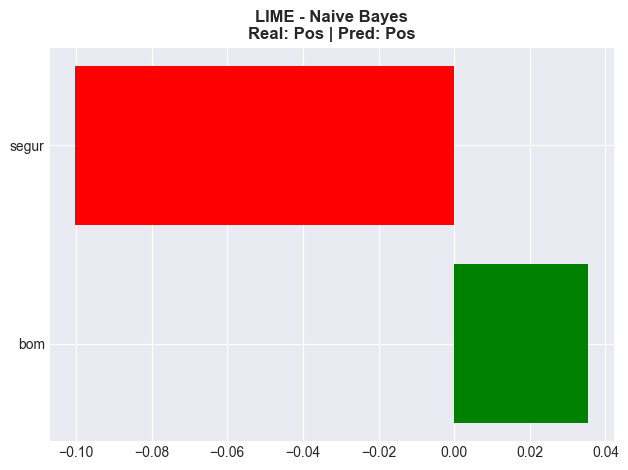


💾 Explicação LIME salva: ../results/figures/04_lime_explicacao.png


In [18]:
melhor_modelo = resultado_nb['modelo']
nome_modelo = resultado_nb['nome']

print(f"🔍 Aplicando LIME no modelo: {nome_modelo}")

# Criar explainer
explainer = LimeTextExplainer(class_names=['Negativo', 'Neutro', 'Positivo'])

# Selecionar um exemplo de teste
idx_exemplo = 10
texto_exemplo = X_test.iloc[idx_exemplo]
sentimento_real = y_test.iloc[idx_exemplo]
sentimento_pred = resultado_lr['predicoes'][idx_exemplo]

print(f"\n📝 Exemplo selecionado (índice {idx_exemplo}):")
print(f"   Texto original: {df['texto'].iloc[X_test.index[idx_exemplo]][:100]}...")
print(f"   Real: {['Negativo', 'Neutro', 'Positivo'][sentimento_real]}")
print(f"   Predito: {['Negativo', 'Neutro', 'Positivo'][sentimento_pred]}")
print(f"   {'✅ ACERTO' if sentimento_real == sentimento_pred else '❌ ERRO'}")

# Função de predição para LIME
def predict_proba_lime(texts):
    return melhor_modelo.predict_proba(tfidf.transform(texts))

# Gerar explicação
exp = explainer.explain_instance(
    texto_exemplo,
    predict_proba_lime,
    num_features=10,
    num_samples=1000
)

print(f"\n🔍 Palavras mais importantes para a predição:")
for palavra, peso in exp.as_list():
    sinal = '+' if peso > 0 else ''
    print(f"   {palavra:15s} → {sinal}{peso:.3f}")

# Visualizar
fig = exp.as_pyplot_figure()
plt.title(f'LIME - {nome_modelo}\nReal: {["Neg", "Neu", "Pos"][sentimento_real]} | '
          f'Pred: {["Neg", "Neu", "Pos"][sentimento_pred]}',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/04_lime_explicacao.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Explicação LIME salva: ../results/figures/04_lime_explicacao.png")

## 📋 12. RESUMO FINAL

In [21]:
print("="*80)
print("📋 RESUMO DO NOTEBOOK 4 - TF-IDF + 5 MODELOS ML")
print("="*80)

print(f"\n✅ Processos concluídos:")
print(f"   1. Vetorização TF-IDF (5000 features)")
print(f"   2. Treinamento de 5 modelos de ML")
print(f"   3. Avaliação completa com métricas")
print(f"   4. Matrizes de confusão geradas")
print(f"   5. Interpretabilidade com LIME e SHAP")

print(f"\n📊 Melhor modelo: {df_resultados.iloc[0]['Modelo']}")
print(f"   F1-Score: {df_resultados.iloc[0]['F1-Score']:.4f}")
print(f"   Acurácia: {df_resultados.iloc[0]['Acurácia']:.4f}")

print(f"\n📁 Arquivos gerados:")
print(f"   Modelos:")
print(f"   • ../results/models/tfidf_vectorizer.pkl")
print(f"   • ../results/models/naive_bayes_tfidf.pkl")
print(f"   • ../results/models/svm_tfidf.pkl")
print(f"   • ../results/models/random_forest_tfidf.pkl")
print(f"   • ../results/models/regressão_logística_tfidf.pkl")
print(f"   • ../results/models/gradient_boosting_tfidf.pkl")

print(f"\n   Métricas:")
print(f"   • ../results/metrics/04_metricas_tfidf.csv")

print(f"\n   Figuras:")
print(f"   • ../results/figures/04_comparacao_metricas.png")
print(f"   • ../results/figures/04_matrizes_confusao.png")
print(f"   • ../results/figures/04_lime_explicacao.png")
print(f"   • ../results/figures/04_shap_summary.png")
print(f"   • ../results/figures/04_feature_importance.png")

print(f"\n➡️  Próximo: Notebook 5 - Métodos Lexicais (SentiLex)")
print("="*80)

📋 RESUMO DO NOTEBOOK 4 - TF-IDF + 5 MODELOS ML

✅ Processos concluídos:
   1. Vetorização TF-IDF (5000 features)
   2. Treinamento de 5 modelos de ML
   3. Avaliação completa com métricas
   4. Matrizes de confusão geradas
   5. Interpretabilidade com LIME e SHAP

📊 Melhor modelo: Naive Bayes
   F1-Score: 0.6489
   Acurácia: 0.6504

📁 Arquivos gerados:
   Modelos:
   • ../results/models/tfidf_vectorizer.pkl
   • ../results/models/naive_bayes_tfidf.pkl
   • ../results/models/svm_tfidf.pkl
   • ../results/models/random_forest_tfidf.pkl
   • ../results/models/regressão_logística_tfidf.pkl
   • ../results/models/gradient_boosting_tfidf.pkl

   Métricas:
   • ../results/metrics/04_metricas_tfidf.csv

   Figuras:
   • ../results/figures/04_comparacao_metricas.png
   • ../results/figures/04_matrizes_confusao.png
   • ../results/figures/04_lime_explicacao.png
   • ../results/figures/04_shap_summary.png
   • ../results/figures/04_feature_importance.png

➡️  Próximo: Notebook 5 - Métodos Lexicai